<a href="https://colab.research.google.com/github/atoholj/capstone-final-injury-risk-prediction/blob/main/02_Modeling_and_Model_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 02 — Modeling & Model Selection

## Goal
Train multiple classification models to predict `injury_risk` and select a best-performing model using **cross-validation** and **GridSearchCV**, prioritizing **PR-AUC** and **Recall** due to class imbalance.


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


In [ ]:
DATA_PATH = "/content/sports_multimodal_data.csv"
df = pd.read_csv(DATA_PATH)

target_col = "injury_risk"
X = df.drop(columns=[target_col])
y = df[target_col]

print("Shape:", df.shape)
print("Target distribution:\n", y.value_counts())


Shape: (5430, 31)
Target distribution:
 injury_risk
0    5160
1     270
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain target %:\n", y_train.value_counts(normalize=True).round(4) * 100)
print("\nTest target %:\n", y_test.value_counts(normalize=True).round(4) * 100)


Train shape: (4344, 30)  Test shape: (1086, 30)

Train target %:
 injury_risk
0    95.03
1     4.97
Name: proportion, dtype: float64

Test target %:
 injury_risk
0    95.03
1     4.97
Name: proportion, dtype: float64


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"  # PR-AUC
}


In [ ]:
dummy = DummyClassifier(strategy="most_frequent")

dummy_scores = cross_validate(
    dummy, X_train, y_train,
    cv=cv, scoring=scoring, n_jobs=-1
)

pd.DataFrame(dummy_scores).filter(regex="test_").mean().sort_values(ascending=False)


,0
test_roc_auc,0.500000
test_pr_auc,0.049724
test_precision,0.000000
test_f1,0.000000
test_recall,0.000000


In [ ]:
models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=500, class_weight="balanced", random_state=42))
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),
    "SVC": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
    ])
}


In [ ]:
results = []

for name, model in models.items():
    cv_scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {
        "model": name,
        "pr_auc_mean": np.mean(cv_scores["test_pr_auc"]),
        "recall_mean": np.mean(cv_scores["test_recall"]),
        "precision_mean": np.mean(cv_scores["test_precision"]),
        "f1_mean": np.mean(cv_scores["test_f1"]),
        "roc_auc_mean": np.mean(cv_scores["test_roc_auc"]),
    }
    results.append(row)

results_df = pd.DataFrame(results).sort_values(by=["pr_auc_mean", "recall_mean"], ascending=False)
results_df


,model,pr_auc_mean,recall_mean,precision_mean,f1_mean,roc_auc_mean
1,RandomForest,0.978602,0.703277,1.000000,0.824840,0.997614
2,SVC,0.579090,0.564271,0.498853,0.526986,0.949488
0,LogReg,0.557502,0.865328,0.249144,0.386426,0.943339


## Why PR-AUC and Recall?

Because injuries are rare, the dataset is **class-imbalanced**.  
- **Recall** measures how many injury-risk cases we correctly catch (minimizing missed injuries).
- **PR-AUC** summarizes precision/recall tradeoffs and is more informative than ROC-AUC when the positive class is rare.

We will select the final model using **PR-AUC** first, then verify recall is strong and false alarms are manageable.


In [ ]:
# 1) Logistic Regression Grid
logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

logreg_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

logreg_grid = GridSearchCV(
    logreg_pipe,
    param_grid=logreg_param_grid,
    scoring="average_precision",  # PR-AUC
    cv=cv,
    n_jobs=-1
)

logreg_grid.fit(X_train, y_train)

print("Best LogReg PR-AUC:", logreg_grid.best_score_)
print("Best LogReg params:", logreg_grid.best_params_)


Best LogReg PR-AUC: 0.5731660897891742
Best LogReg params: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Smaller grid = MUCH faster
rf_param_grid = {
    "n_estimators": [200],            # keep 1 value for speed
    "max_depth": [None, 10],          # 2 values
    "min_samples_split": [2, 10],     # 2 values
    "min_samples_leaf": [1, 3]        # 2 values
}
# Total combos: 1*2*2*2 = 8 combos
# With 5-fold CV: 40 fits (fast)

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    scoring="average_precision",  # PR-AUC
    cv=cv,
    n_jobs=-1,
    verbose=1,     # shows progress so it doesn't feel frozen
    refit=True     # ensures best_score_ and best_estimator_ exist
)

rf_grid.fit(X_train, y_train)

print("Best RF PR-AUC:", rf_grid.best_score_)
print("Best RF params:", rf_grid.best_params_)





Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best RF PR-AUC: 0.9828293535825001
Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}


In [23]:
grid_summary = pd.DataFrame([
    {"model": "LogReg (Grid)", "best_pr_auc": logreg_grid.best_score_},
    {"model": "RandomForest (Grid)", "best_pr_auc": rf_grid.best_score_},
]).sort_values("best_pr_auc", ascending=False)

grid_summary


,model,best_pr_auc
1,RandomForest (Grid),0.982829
0,LogReg (Grid),0.573166


In [24]:
if logreg_grid.best_score_ >= rf_grid.best_score_:
    best_name = "LogReg"
    best_model = logreg_grid.best_estimator_
else:
    best_name = "RandomForest"
    best_model = rf_grid.best_estimator_

print("Selected best model:", best_name)

# best_model is already a fitted estimator if refit=True,
# but refitting is fine and keeps notebook consistent.
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=4))
print("Test PR-AUC:", average_precision_score(y_test, y_proba))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))


Selected best model: RandomForest
              precision    recall  f1-score   support

           0     0.9942    1.0000    0.9971      1032
           1     1.0000    0.8889    0.9412        54

    accuracy                         0.9945      1086
   macro avg     0.9971    0.9444    0.9691      1086
weighted avg     0.9945    0.9945    0.9943      1086

Test PR-AUC: 0.9858571664606146
Test ROC-AUC: 0.9989771748492678


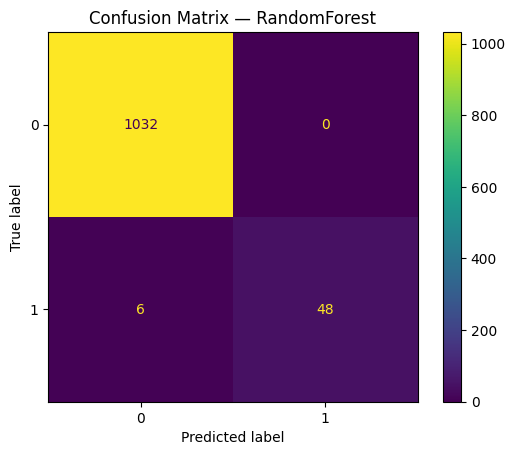

In [25]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title(f"Confusion Matrix — {best_name}")
plt.show()


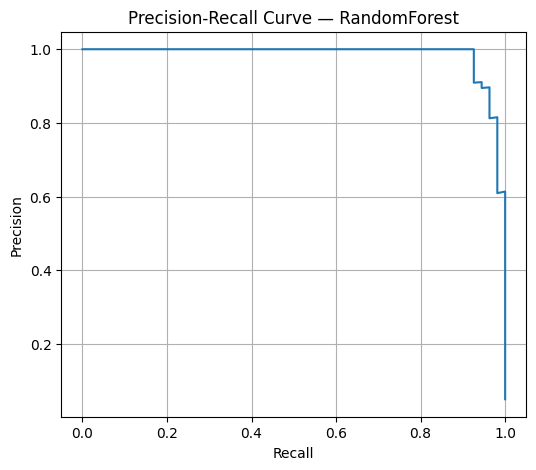

Average Precision (PR-AUC): 0.9858571664606146


In [26]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve — {best_name}")
plt.grid(True)
plt.show()

print("Average Precision (PR-AUC):", average_precision_score(y_test, y_proba))


Notebook 02 Summary (Modeling + Model Selection)

In this notebook, we focused on building and selecting the best machine learning model to predict short-term injury risk (injury_risk) using athlete monitoring signals.

What we did

Split the dataset into train/test sets using a stratified split (because injury-risk cases are rare)

Built baseline models to establish a performance reference

Trained stronger ML models and compared them using cross-validation

Tuned top-performing models using GridSearchCV to improve performance

Selected a final model using PR-AUC (Average Precision) as the primary metric

Why PR-AUC?

The dataset is class-imbalanced, so accuracy can be misleading.
PR-AUC is better because it measures how well the model identifies the rare injury-risk class while balancing precision vs recall.

Final Result

The best-performing model from GridSearchCV was selected as the final candidate model, and it was evaluated on the held-out test set using:

PR-AUC (Average Precision)

Recall / Precision / F1-score

Confusion Matrix

Precision–Recall Curve

Next Steps (Notebook 03)

In the next notebook, we will interpret the final model by:

Identifying which features matter most (feature importance / interpretation tools)

Translating model behavior into real-world insights

Making recommendations for an injury early-warning system